# Canonical quantum neurons vs. classical PINNs on a 7D screened Poisson equation

We compare two quantum neurons (TFIM and IM) with two classical PINNs (one and two hidden layers).
Expectation values are computed exactly by statevector simulation; gradients use automatic differentiation.

## Problem

On the torus $z\in[0,2\pi)^7$ with periodic boundary conditions:

$$
\boxed{(\lambda-\Delta)\,u(z)=\mathrm{Tr}\big[H^\star\rho(z)\big],\qquad \lambda=1}
$$

$$
\rho(z)=e^{-\frac i2\sum_{q}z_q\sigma_Y^{(q)}}\,|0\rangle\langle0|^{\otimes7}\,e^{\frac i2\sum_{q}z_q\sigma_Y^{(q)}},\qquad
H^\star=\sum_{q=1}^{6}W_q\,Z_qZ_{q+1}+\sum_{q=1}^{7}w_q\,X_q+b\,I,
$$

with $W_q,w_q,b\sim\mathcal N(0,1)$ (8 random instances). Since $\mathrm{Tr}[H^\star\rho(z)]=\sum_qW_q\cos z_q\cos z_{q+1}+\sum_qw_q\sin z_q+b$, the exact solution is

$$
u^\star(z)=\sum_{q}\frac{W_q}{\lambda+2}\cos z_q\cos z_{q+1}+\sum_{q}\frac{w_q}{\lambda+1}\sin z_q+\frac{b}{\lambda}.
$$

It is used only to measure the error.

## Models

| Model | Ansatz | Trainable parameters |
|---|---|---|
| Quantum TFIM | $c\,\mathrm{Tr}\big[\tanh(H_{\rm TFIM}(\theta))\rho(z)\big]$, $\ H_{\rm TFIM}=\sum_q W_qZ_qZ_{q+1}+\sum_q w_qX_q+bI$ | 14 |
| Quantum IM | $c\,\mathrm{Tr}\big[\tanh(H_{\rm IM}(\theta))\rho(z)\big]$, $\ H_{\rm IM}=\sum_q W_qZ_qZ_{q+1}+\sum_q w_qZ_q+bI$ | 14 |
| PINN, 1 hidden layer | tanh network on $(\cos z,\sin z)\in\mathbb R^{14}$, width 1 | 17 |
| PINN, 2 hidden layers | tanh network on $(\cos z,\sin z)$, widths (1, 1) | 19 |

- The output scale $c=(\sum|W_q|+\sum|w_q|+|b|)/\lambda$ is fixed by the PDE data (it bounds $|u^\star|$ by the maximum principle). Both quantum neurons start from the same $\theta$.
- Quantum residual: $(\lambda-\Delta)\rho(z)=(\lambda+\tfrac n2)\rho(z)-\tfrac12\sum_q\rho(z+\pi e_q)$, so
  $r(z)=c\,\mathrm{Tr}\big[\tanh(H(\theta))\big((\lambda+\tfrac n2)\rho(z)-\tfrac12\sum_q\rho(z+\pi e_q)\big)\big]-\mathrm{Tr}[H^\star\rho(z)]$ uses 8 encoded states per point.
  PINN residuals use automatic differentiation.
- Training: the same 1024 random collocation points for all models, loss $\frac1M\sum_m r(z_m)^2$, Adam with learning rate $10^{-2}\to10^{-4}$ (exponential decay), 500 epochs.
  The 8 instances are trained in parallel as a batch. Errors are measured on 4096 random test points.

In [1]:
import math
import time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import qmps as qmp

torch.set_default_dtype(torch.float64)
DTYPE = torch.float64
DEVICE = torch.device("cpu")

N_QUBITS = 7                                  # one qubit per coordinate
LAMBDA = 1.0
N_INSTANCES = 8                               # random H* = independent PDE instances
N_COLLOC = 1024
N_TEST = 4096
EPOCHS = 500
LR0, LR_MIN = 1e-2, 1e-4
INIT_SCALE = 0.05
PINN_WIDTHS = {"PINN-1": (1,), "PINN-2": (1, 1)}
SEED = 2026

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
NAMES = ["TFIM", "IM", "PINN-1", "PINN-2"]
COLORS = {"TFIM": "#2a78d6", "IM": "#e34948", "PINN-1": "#eda100", "PINN-2": "#1baf7a"}
STYLES = {"TFIM": "-", "IM": "--", "PINN-1": (0, (6, 1.5, 1.5, 1.5)), "PINN-2": ":"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2.0, "legend.frameon": False,
})

In [2]:
# ---------- models ----------
_PAULI = {
    "I": torch.eye(2, dtype=DTYPE),
    "X": torch.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=DTYPE),
    "Z": torch.tensor([[1.0, 0.0], [0.0, -1.0]], dtype=DTYPE),
}


def pauli_string(label):
    out = torch.ones(1, 1, dtype=DTYPE)
    for ch in label:
        out = torch.kron(out, _PAULI[ch])
    return out


def ising_basis(coupling, field):
    # H(theta) = sum_q W_q C_q C_{q+1} + sum_q w_q F_q + b I, parameters ordered (W_1..W_6, w_1..w_7, b)
    n = N_QUBITS
    labels = ["".join(coupling if k in (q, q + 1) else "I" for k in range(n)) for q in range(n - 1)]
    labels += ["".join(field if k == q else "I" for k in range(n)) for q in range(n)]
    labels += ["I" * n]
    return torch.stack([pauli_string(s) for s in labels])


BASIS = {"TFIM": ising_basis("Z", "X"), "IM": ising_basis("Z", "Z")}
N_H = BASIS["TFIM"].shape[0]                  # 14 parameters


class MatrixTanh(torch.autograd.Function):
    # tanh(H) by eigendecomposition; exact backward (Daleckii-Krein), stable for the degenerate IM spectrum

    @staticmethod
    def forward(ctx, H):
        lam, V = torch.linalg.eigh(H)
        f = torch.tanh(lam)
        ctx.save_for_backward(lam, V, f)
        return (V * f.unsqueeze(-2)) @ V.mT

    @staticmethod
    def backward(ctx, grad_G):
        lam, V, f = ctx.saved_tensors
        dlam = lam.unsqueeze(-1) - lam.unsqueeze(-2)
        deriv = 1.0 - torch.tanh(0.5 * (lam.unsqueeze(-1) + lam.unsqueeze(-2))) ** 2
        close = dlam.abs() < 1e-10
        divided = torch.where(close, deriv, (f.unsqueeze(-1) - f.unsqueeze(-2)) / torch.where(close, torch.ones_like(dlam), dlam))
        sym = 0.5 * (grad_G + grad_G.mT)
        return V @ ((V.mT @ sym @ V) * divided) @ V.mT


class QuantumNeuron(torch.nn.Module):
    # one neuron per PDE instance: u_b(z) = c_b Tr[tanh(H(theta_b)) rho(z)], c_b fixed by the PDE data

    def __init__(self, family, theta0, scale):
        super().__init__()
        self.register_buffer("basis", BASIS[family])
        self.register_buffer("scale", scale.clone())
        self.theta = torch.nn.Parameter(theta0.clone())

    def observable(self):
        return MatrixTanh.apply(torch.einsum("bj,jkl->bkl", self.theta, self.basis))


def pinn_param_count(widths):
    dims = [2 * N_QUBITS, *widths, 1]
    return sum(o * (i + 1) for i, o in zip(dims[:-1], dims[1:]))


class PINN(torch.nn.Module):
    # one tanh network per PDE instance: u_b(z) = MLP_b(cos z, sin z)

    def __init__(self, widths, gen):
        super().__init__()
        dims = [2 * N_QUBITS, *widths, 1]
        self.W, self.b = torch.nn.ParameterList(), torch.nn.ParameterList()
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            lim = math.sqrt(6.0 / (d_in + d_out))   # Xavier-uniform
            self.W.append(torch.nn.Parameter(lim * (2 * torch.rand(N_INSTANCES, d_out, d_in, generator=gen) - 1)))
            self.b.append(torch.nn.Parameter(torch.zeros(N_INSTANCES, d_out)))

    def forward(self, z):                          # z: (B, N, n) -> (B, N)
        h = torch.cat([torch.cos(z), torch.sin(z)], dim=-1)
        for layer, (W, b) in enumerate(zip(self.W, self.b)):
            h = torch.einsum("bmi,boi->bmo", h, W) + b[:, None, :]
            if layer < len(self.W) - 1:
                h = torch.tanh(h)
        return h[..., 0]


N_PARAMS = {"TFIM": N_H, "IM": N_H, **{k: pinn_param_count(w) for k, w in PINN_WIDTHS.items()}}
LABELS = {
    "TFIM": f"Quantum TFIM ({N_PARAMS['TFIM']} params)",
    "IM": f"Quantum IM ({N_PARAMS['IM']} params)",
    "PINN-1": f"PINN, 1 hidden layer ({N_PARAMS['PINN-1']} params)",
    "PINN-2": f"PINN, 2 hidden layers ({N_PARAMS['PINN-2']} params)",
}

In [3]:
# ---------- encoding and PDE data ----------
def encoded_states(z):
    # |psi(z)> = prod_q RY(z_q)|0>  (real amplitudes)
    lead = z.shape[:-1]
    flat = z.reshape(-1, N_QUBITS)
    state = qmp.State(N_QUBITS, batch_size=flat.shape[0], dtype=DTYPE, device=DEVICE)
    for q in range(N_QUBITS):
        qmp.RY(state, flat[:, q], wires=q)
    return state.real.reshape(*lead, 2**N_QUBITS)


def expectation(G, psi):
    # Tr[G |psi><psi|] for G (B, d, d), psi (N, d) -> (B, N)
    return (torch.einsum("bij,nj->bni", G, psi) * psi).sum(-1)


def residual_operator(z):
    # (lambda - Laplacian) rho(z) = (lambda + n/2) rho(z) - 1/2 sum_q rho(z + pi e_q): 8 states per point
    shifts = torch.cat([torch.zeros(1, N_QUBITS), math.pi * torch.eye(N_QUBITS)])
    coef = torch.tensor([LAMBDA + N_QUBITS / 2] + [-0.5] * N_QUBITS)
    psi = encoded_states(z[:, None, :] + shifts[None])
    return torch.einsum("k,mki,mkj->mij", coef, psi, psi)


def rotor_energy(z, params):
    # Tr[H rho(z)] for H = sum W ZZ + sum w X + b I  ->  (B, N)
    W, w, b = params[:, : N_QUBITS - 1], params[:, N_QUBITS - 1 : -1], params[:, -1]
    c, s = torch.cos(z), torch.sin(z)
    return (W[:, None] * c[None, :, :-1] * c[None, :, 1:]).sum(-1) + (w[:, None] * s[None]).sum(-1) + b[:, None]


def exact_solution(z, params):
    W, w, b = params[:, : N_QUBITS - 1], params[:, N_QUBITS - 1 : -1], params[:, -1:]
    return rotor_energy(z, torch.cat([W / (LAMBDA + 2), w / (LAMBDA + 1), b / LAMBDA], dim=1))


gen = torch.Generator().manual_seed(SEED)
zeta = torch.randn(N_INSTANCES, N_H, generator=gen)                    # coefficients of the 8 Hamiltonians H*
theta0 = INIT_SCALE * torch.randn(N_INSTANCES, N_H, generator=gen)     # shared initialization of both quantum neurons
z_col = 2 * math.pi * torch.rand(N_COLLOC, N_QUBITS, generator=gen)
z_test = 2 * math.pi * torch.rand(N_TEST, N_QUBITS, generator=gen)

Sigma = residual_operator(z_col).reshape(N_COLLOC, -1)
psi_test = encoded_states(z_test)
f_col = rotor_energy(z_col, zeta)                 # source Tr[H* rho(z)] at the collocation points
u_test = exact_solution(z_test, zeta)             # exact solution, used only for the error
scale = zeta.abs().sum(1) / LAMBDA                # output scale c of the quantum neurons

In [4]:
# ---------- training ----------
F_MS = f_col.pow(2).mean(1)


def quantum_residual(m):
    G = m.observable()
    return m.scale[:, None] * (G.reshape(N_INSTANCES, -1) @ Sigma.T) - f_col


def quantum_predict(m):
    return m.scale[:, None] * expectation(m.observable(), psi_test)


def pinn_residual(m):
    z = z_col.expand(N_INSTANCES, -1, -1).clone().requires_grad_(True)
    u = m(z)
    grad = torch.autograd.grad(u.sum(), z, create_graph=True)[0]
    lap = sum(torch.autograd.grad(grad[..., i].sum(), z, create_graph=True)[0][..., i] for i in range(N_QUBITS))
    return LAMBDA * u - lap - f_col


def pinn_predict(m):
    return m(z_test.expand(N_INSTANCES, -1, -1))


def train(model, residual, predict):
    opt = torch.optim.Adam(model.parameters(), lr=LR0)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda e: (LR_MIN / LR0) ** (min(e, EPOCHS) / EPOCHS))
    losses = []
    for epoch in range(EPOCHS):
        loss = residual(model).pow(2).mean(1)                    # one loss per PDE instance
        losses.append((loss / F_MS).detach())                    # relative PDE residual
        opt.zero_grad()
        loss.sum().backward()
        opt.step()
        sched.step()
    with torch.no_grad():
        error = torch.linalg.norm(predict(model) - u_test, dim=1) / torch.linalg.norm(u_test, dim=1)
    return torch.stack(losses).numpy(), error.numpy()


losses, errors, models = {}, {}, {}
for name in NAMES:
    t0 = time.time()
    if name in BASIS:
        model = QuantumNeuron(name, theta0, scale)
        losses[name], errors[name] = train(model, quantum_residual, quantum_predict)
    else:
        model = PINN(PINN_WIDTHS[name], torch.Generator().manual_seed(SEED + len(PINN_WIDTHS[name])))
        losses[name], errors[name] = train(model, pinn_residual, pinn_predict)
    models[name] = model
    print(f"{LABELS[name]:34s} {time.time() - t0:5.1f}s | median final residual {np.median(losses[name][-1]):.2e} "
          f"| median rel. L2 error {np.median(errors[name]):.2e}")

Quantum TFIM (14 params)            18.0s | median final residual 1.33e-04 | median rel. L2 error 6.25e-03
Quantum IM (14 params)              15.3s | median final residual 6.44e-01 | median rel. L2 error 8.49e-01
PINN, 1 hidden layer (17 params)    19.5s | median final residual 4.14e-01 | median rel. L2 error 4.65e-01
PINN, 2 hidden layers (19 params)   19.1s | median final residual 4.02e-01 | median rel. L2 error 4.66e-01


## Results

PDE residual loss during training (median over the 8 instances, shaded: min–max), the final relative $L^2$ error of each instance, and the learned functions on a 2D slice.

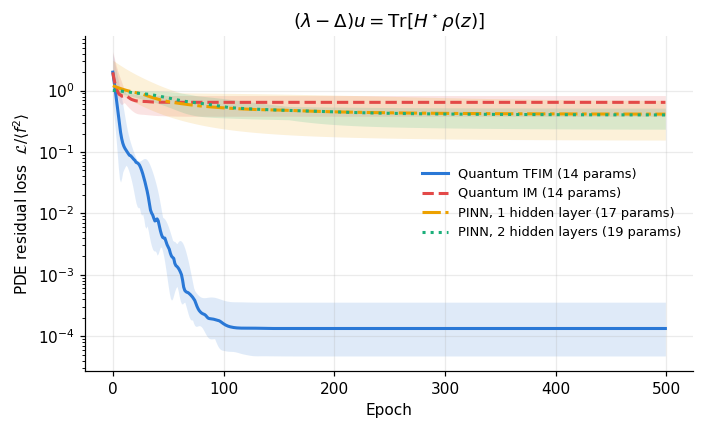

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
epochs = np.arange(EPOCHS)
for name in NAMES:
    ax.fill_between(epochs, losses[name].min(1), losses[name].max(1), color=COLORS[name], alpha=0.15, lw=0)
    ax.plot(epochs, np.median(losses[name], 1), color=COLORS[name], ls=STYLES[name], label=LABELS[name])
ax.set(yscale="log", xlabel="Epoch", ylabel=r"PDE residual loss  $\mathcal{L}/\langle f^2\rangle$",
       title=r"$(\lambda-\Delta)u=\mathrm{Tr}[H^\star\rho(z)]$")
ax.legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "tfim_source_residual_loss.png", bbox_inches="tight")
plt.show()

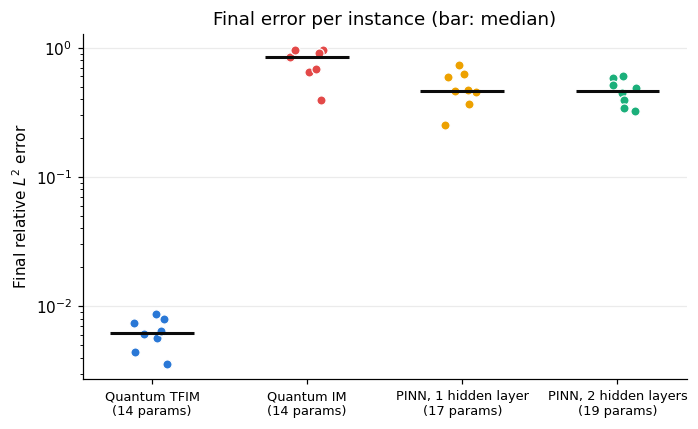

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
rng = np.random.default_rng(0)
for i, name in enumerate(NAMES):
    y = errors[name]
    ax.scatter(i + rng.uniform(-0.12, 0.12, len(y)), y, s=36, color=COLORS[name], edgecolor="white", linewidth=0.8, zorder=3)
    ax.hlines(np.median(y), i - 0.27, i + 0.27, color="#0b0b0b", lw=2, zorder=4)
ax.set_xticks(range(len(NAMES)), [LABELS[n].replace(" (", "\n(") for n in NAMES], fontsize=8.5)
ax.set(yscale="log", ylabel=r"Final relative $L^2$ error", title="Final error per instance (bar: median)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "tfim_source_final_errors.png", bbox_inches="tight")
plt.show()

**Solution slice.** $(z_1,z_2)$ varied, the other five coordinates fixed at random values (instance 0): analytical solution and the four approximations.

In [ ]:
grid_n = 81
axis = torch.linspace(0.0, 2 * math.pi, grid_n)
Z1, Z2 = torch.meshgrid(axis, axis, indexing="ij")
z_fixed = 2 * math.pi * torch.rand(N_QUBITS, generator=torch.Generator().manual_seed(SEED + 7))
z_slice = z_fixed.repeat(grid_n * grid_n, 1)
z_slice[:, 0], z_slice[:, 1] = Z1.reshape(-1), Z2.reshape(-1)
b0 = 0                                            # instance shown

with torch.no_grad():
    U = {"Exact": exact_solution(z_slice, zeta[b0:b0 + 1])[0]}
    psi_slice = encoded_states(z_slice)
    for name in NAMES:
        m = models[name]
        if name in BASIS:
            U[name] = m.scale[b0] * expectation(m.observable()[b0:b0 + 1], psi_slice)[0]
        else:
            U[name] = m(z_slice.expand(N_INSTANCES, -1, -1))[b0]

titles = {"Exact": r"Analytical solution $u^\star$", **{n: LABELS[n].replace(" (", "\n(") for n in NAMES}}
vmax = float(max(v.abs().max() for v in U.values()))
fig, axes = plt.subplots(1, 5, figsize=(18, 3.9), constrained_layout=True)
for ax, key in zip(axes, ["Exact", *NAMES]):
    im = ax.pcolormesh(Z1.numpy(), Z2.numpy(), U[key].reshape(grid_n, grid_n).numpy(),
                       cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
    ax.set_title(titles[key], fontsize=9.5)
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_xticks([0, math.pi, 2 * math.pi], ["0", r"$\pi$", r"$2\pi$"])
    ax.set_yticks([0, math.pi, 2 * math.pi], ["0", r"$\pi$", r"$2\pi$"])
    ax.set_xlabel(r"$z_1$")
    ax.set_ylabel(r"$z_2$")
fig.colorbar(im, ax=axes, shrink=0.85, label=r"$u(z)$")
fig.savefig(FIG_DIR / "tfim_source_solution_slice.png", bbox_inches="tight")
plt.show()